# NHL Puck Management — Composite Score

This notebook combines all three puck management metrics into a single 
composite score for every NHL skater in the 2025-26 regular season.

**The three metrics:**
1. Turnover metric (takeaway_per_60 - giveaway_per_60)
2. Giveaway above expected (calculated in the notebook 02_modeling)
3. Defensive zone giveaway rate (adjusted for zone starts)

Each metric is MAD z-scored within position groups, confidence weighted 
based on ice time, then combined into a final composite score.

In [38]:
import pandas as pd
import numpy as np
from scipy.stats import median_abs_deviation
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [143]:
skaters = pd.read_csv('../data/processed/skaters.csv')
skaters = skaters[skaters['situation'] == '5on5'].copy()

# Load player giveaways (above expected metric)
player_giveaways = pd.read_csv('../data/processed/player_giveaways.csv')

print(f"Skaters shape: {skaters.shape}")
print(f"Player giveaways shape: {player_giveaways.shape}")

Skaters shape: (940, 154)
Player giveaways shape: (914, 5)


## Metric 1 — Turnover Metric

Takeaway rate per 60 minus giveaway rate per 60. A positive value means 
the player wins more pucks than they lose. Calculated from MoneyPuck 
5on5 skater data.

In [144]:
# Metric 1 — Giveaway rate per 60 (lower is better)
skaters['giveaway_metric'] = (skaters['I_F_giveaways'] / skaters['icetime']) * 3600

print(f"Giveaway per 60 stats:")
print(skaters['giveaway_metric'].describe())

Giveaway per 60 stats:
count   940.0000
mean      3.1325
std       1.3152
min       0.0000
25%       2.4679
50%       3.0498
75%       3.7358
max      13.9211
Name: giveaway_metric, dtype: float64


## Metric 3 — Defensive Zone Giveaway Rate

Dzone giveaways per defensive zone shift start. Adjusted for zone 
deployment so players who start more shifts in the dzone are not 
unfairly penalised. Lower is better.

In [145]:
# Replace inf with NaN for players with 0 dzone shift starts
skaters['dzone_giveaway_metric'] = (
    skaters['I_F_dZoneGiveaways'] / skaters['I_F_dZoneShiftStarts']
).replace([np.inf, -np.inf], np.nan)


print(f"Players with NaN dzone rate: {skaters['dzone_giveaway_metric'].isna().sum()}")
print(f"\nDzone giveaway rate stats:")
print(skaters['dzone_giveaway_metric'].describe())
skaters.head()

Players with NaN dzone rate: 20

Dzone giveaway rate stats:
count   920.0000
mean      0.2098
std       0.2197
min       0.0000
25%       0.0832
50%       0.1564
75%       0.2786
max       2.5000
Name: dzone_giveaway_metric, dtype: float64


,playerId,season,name,team,position,situation,games_played,icetime,shifts,gameScore,onIce_xGoalsPercentage,offIce_xGoalsPercentage,onIce_corsiPercentage,offIce_corsiPercentage,onIce_fenwickPercentage,offIce_fenwickPercentage,iceTimeRank,I_F_xOnGoal,I_F_xGoals,I_F_xRebounds,I_F_xFreeze,I_F_xPlayStopped,I_F_xPlayContinuedInZone,I_F_xPlayContinuedOutsideZone,I_F_flurryAdjustedxGoals,I_F_scoreVenueAdjustedxGoals,I_F_flurryScoreVenueAdjustedxGoals,I_F_primaryAssists,I_F_secondaryAssists,I_F_shotsOnGoal,I_F_missedShots,I_F_blockedShotAttempts,I_F_shotAttempts,I_F_points,I_F_goals,I_F_rebounds,I_F_reboundGoals,I_F_freeze,I_F_playStopped,I_F_playContinuedInZone,I_F_playContinuedOutsideZone,I_F_savedShotsOnGoal,I_F_savedUnblockedShotAttempts,penalties,I_F_penalityMinutes,I_F_faceOffsWon,I_F_hits,I_F_takeaways,I_F_giveaways,I_F_lowDangerShots,I_F_mediumDangerShots,I_F_highDangerShots,I_F_lowDangerxGoals,I_F_mediumDangerxGoals,I_F_highDangerxGoals,I_F_lowDangerGoals,I_F_mediumDangerGoals,I_F_highDangerGoals,I_F_scoreAdjustedShotsAttempts,I_F_unblockedShotAttempts,I_F_scoreAdjustedUnblockedShotAttempts,I_F_dZoneGiveaways,I_F_xGoalsFromxReboundsOfShots,I_F_xGoalsFromActualReboundsOfShots,I_F_reboundxGoals,I_F_xGoals_with_earned_rebounds,I_F_xGoals_with_earned_rebounds_scoreAdjusted,I_F_xGoals_with_earned_rebounds_scoreFlurryAdjusted,I_F_shifts,I_F_oZoneShiftStarts,I_F_dZoneShiftStarts,I_F_neutralZoneShiftStarts,I_F_flyShiftStarts,I_F_oZoneShiftEnds,I_F_dZoneShiftEnds,I_F_neutralZoneShiftEnds,I_F_flyShiftEnds,faceoffsWon,faceoffsLost,timeOnBench,penalityMinutes,penalityMinutesDrawn,penaltiesDrawn,shotsBlockedByPlayer,OnIce_F_xOnGoal,OnIce_F_xGoals,OnIce_F_flurryAdjustedxGoals,OnIce_F_scoreVenueAdjustedxGoals,OnIce_F_flurryScoreVenueAdjustedxGoals,OnIce_F_shotsOnGoal,OnIce_F_missedShots,OnIce_F_blockedShotAttempts,OnIce_F_shotAttempts,OnIce_F_goals,OnIce_F_rebounds,OnIce_F_reboundGoals,OnIce_F_lowDangerShots,OnIce_F_mediumDangerShots,OnIce_F_highDangerShots,OnIce_F_lowDangerxGoals,OnIce_F_mediumDangerxGoals,OnIce_F_highDangerxGoals,OnIce_F_lowDangerGoals,OnIce_F_mediumDangerGoals,OnIce_F_highDangerGoals,OnIce_F_scoreAdjustedShotsAttempts,OnIce_F_unblockedShotAttempts,OnIce_F_scoreAdjustedUnblockedShotAttempts,OnIce_F_xGoalsFromxReboundsOfShots,OnIce_F_xGoalsFromActualReboundsOfShots,OnIce_F_reboundxGoals,OnIce_F_xGoals_with_earned_rebounds,OnIce_F_xGoals_with_earned_rebounds_scoreAdjusted,OnIce_F_xGoals_with_earned_rebounds_scoreFlurryAdjusted,OnIce_A_xOnGoal,OnIce_A_xGoals,OnIce_A_flurryAdjustedxGoals,OnIce_A_scoreVenueAdjustedxGoals,OnIce_A_flurryScoreVenueAdjustedxGoals,OnIce_A_shotsOnGoal,OnIce_A_missedShots,OnIce_A_blockedShotAttempts,OnIce_A_shotAttempts,OnIce_A_goals,OnIce_A_rebounds,OnIce_A_reboundGoals,OnIce_A_lowDangerShots,OnIce_A_mediumDangerShots,OnIce_A_highDangerShots,OnIce_A_lowDangerxGoals,OnIce_A_mediumDangerxGoals,OnIce_A_highDangerxGoals,OnIce_A_lowDangerGoals,OnIce_A_mediumDangerGoals,OnIce_A_highDangerGoals,OnIce_A_scoreAdjustedShotsAttempts,OnIce_A_unblockedShotAttempts,OnIce_A_scoreAdjustedUnblockedShotAttempts,OnIce_A_xGoalsFromxReboundsOfShots,OnIce_A_xGoalsFromActualReboundsOfShots,OnIce_A_reboundxGoals,OnIce_A_xGoals_with_earned_rebounds,OnIce_A_xGoals_with_earned_rebounds_scoreAdjusted,OnIce_A_xGoals_with_earned_rebounds_scoreFlurryAdjusted,OffIce_F_xGoals,OffIce_A_xGoals,OffIce_F_shotAttempts,OffIce_A_shotAttempts,xGoalsForAfterShifts,xGoalsAgainstAfterShifts,corsiForAfterShifts,corsiAgainstAfterShifts,fenwickForAfterShifts,fenwickAgainstAfterShifts,giveaway_metric,dzone_giveaway_metric
2,8478043,2025,Sam Lafferty,CHI,C,5on5,29,14856.0000,351.0000,0.8300,0.4000,0.4200,0.4700,0.4500,0.4500,0.4500,318.0000,10.2000,0.8500,0.8400,2.6300,0.4200,5.3100,3.9500,0.8000,0.8300,0.7800,0.0000,1.0000,9.0000,5.0000,6.0000,20.0000,2.0000,1.0000,2.0000,0.0000,0.0000,0.0000,4.0000,7.0000,8.0000,13.0000,2.0000,4.0000,25.0000,35.0000,2.0000,15.0000,10.0000,3.0000,1.0000,0.3800,0.2700,0.2000,1.0000,0.0000,0.0000,19.7000,14.0000,13.

In [146]:
# Join skaters with player giveaways
combined = skaters.merge(
    player_giveaways, 
    left_on='name', 
    right_on='player_name', 
    how='left'
)

print(f"Combined shape: {combined.shape}")
print(f"Missing above expected: {combined['avg_above_expected'].isna().sum()}")
combined[['name', 'team', 'position', 'games_played', 'icetime', 
          'giveaway_metric', 'dzone_giveaway_metric', 'avg_above_expected']].head(10)

Combined shape: (940, 161)
Missing above expected: 36


,name,team,position,games_played,icetime,giveaway_metric,dzone_giveaway_metric,avg_above_expected
0,Sam Lafferty,CHI,C,29,14856.0000,3.6349,0.1667,0.0132
1,Travis Mitchell,NYI,D,9,6152.0000,2.9259,0.5000,-0.1012
2,Erik Gudbranson,CBJ,D,37,32374.0000,3.2248,0.2917,-0.0133
3,Mason Marchment,CBJ,L,68,59536.0000,4.7165,0.2151,-0.0008
4,Jacob Bryson,WPG,D,50,31545.0000,1.9401,0.1714,-0.0036
5,Jalen Chatfield,CAR,D,72,73949.0000,3.0183,0.2741,0.0080
6,Mikael Granlund,ANA,C,58,46674.0000,2.8538,0.0863,0.0056
7,Matt Boldy,MIN,L,76,64687.0000,3.5618,0.1141,0.0004
8,Max Domi,TOR,C,80,62271.0000,4.5093,0.1361,0.0029
9,Lawson Crouse,UTA,L,81,60476.0000,2.6192,0.0663,0.0014


## Joining All Three Metrics

We join the MoneyPuck skaters data with our giveaway above expected 
scores using a left join on player name. This keeps all 940 players 
from MoneyPuck and adds the above expected score where available.

**Join details:**
- Left table: MoneyPuck skaters (940 players, 5on5 filtered)
- Right table: Player giveaways — above expected scores (914 players)
- Join key: `name` = `player_name`
- Join type: left join — keeps all MoneyPuck players

**Result:** 940 players with all three metrics:
- `turnover_metric` — calculated from MoneyPuck ✅
- `dzone_giveaway_rate` — calculated from MoneyPuck ✅
- `avg_above_expected` — from our NHL API model ✅

**36 players have missing above expected scores** — these players had 
5on5 ice time in MoneyPuck but never recorded a giveaway in the NHL 
API play-by-play data. These will be handled during confidence weighting.

In [147]:
# Keep only relevant columns
final_df = combined[[
    'name', 'team', 'position', 'games_played', 'icetime',
    'giveaway_metric', 'dzone_giveaway_metric', 'avg_above_expected',
    'total_giveaways'
]].copy()

print(final_df.shape)
final_df.head()

(940, 9)


,name,team,position,games_played,icetime,giveaway_metric,dzone_giveaway_metric,avg_above_expected,total_giveaways
0,Sam Lafferty,CHI,C,29,14856.0000,3.6349,0.1667,0.0132,15.0000
1,Travis Mitchell,NYI,D,9,6152.0000,2.9259,0.5000,-0.1012,5.0000
2,Erik Gudbranson,CBJ,D,37,32374.0000,3.2248,0.2917,-0.0133,29.0000
3,Mason Marchment,CBJ,L,68,59536.0000,4.7165,0.2151,-0.0008,78.0000
4,Jacob Bryson,WPG,D,50,31545.0000,1.9401,0.1714,-0.0036,17.0000


count   940.0000
mean     50.2255
std      29.0725
min       1.0000
25%      22.0000
50%      61.0000
75%      77.0000
max      83.0000
Name: games_played, dtype: float64

Percentiles:
10th: 4 games
25th: 22 games
33rd: 37 games


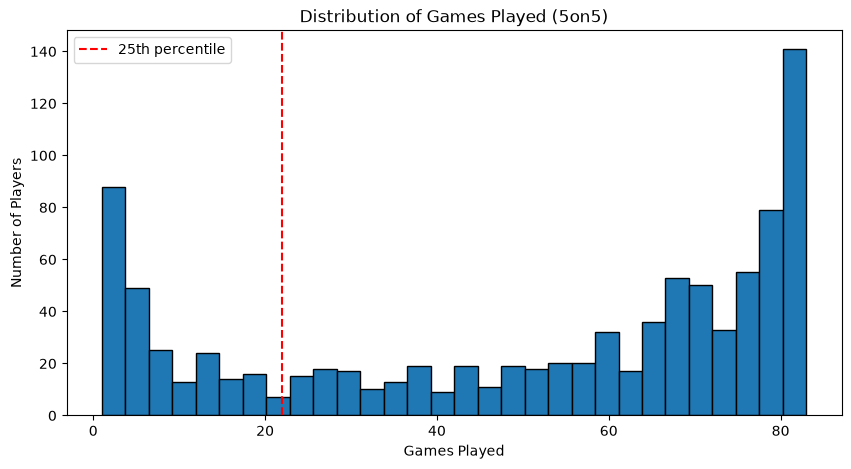

In [148]:
print(final_df['games_played'].describe())
print(f"\nPercentiles:")
print(f"10th: {final_df['games_played'].quantile(0.10):.0f} games")
print(f"25th: {final_df['games_played'].quantile(0.25):.0f} games")
print(f"33rd: {final_df['games_played'].quantile(0.33):.0f} games")

# Distribution
plt.figure(figsize=(10, 5))
plt.hist(final_df['games_played'], bins=30, edgecolor='black')
plt.xlabel('Games Played')
plt.ylabel('Number of Players')
plt.title('Distribution of Games Played (5on5)')
plt.axvline(final_df['games_played'].quantile(0.25), color='red', linestyle='--', label='25th percentile')
plt.legend()
plt.show()

In [149]:
# Hard cutoff at 20 games
final_df = final_df[final_df['games_played'] >= 20].copy()
print(f"Players after 20 game filter: {len(final_df)}")

# Convert icetime to minutes
final_df['icetime_minutes'] = final_df['icetime'] / 60
final_df=final_df.drop(columns=['icetime'])


MIN_ICETIME = 200
MAX_ICETIME = final_df['icetime_minutes'].quantile(0.75)  # 1123 minutes

print(f"Min icetime threshold: {MIN_ICETIME:.0f} minutes")
print(f"Max icetime threshold: {MAX_ICETIME:.0f} minutes")

final_df['confidence'] = (0.30 + 0.70 * (
    (final_df['icetime_minutes'] - MIN_ICETIME) / (MAX_ICETIME - MIN_ICETIME)
).clip(0, 1))

print(f"\nConfidence distribution:")
print(final_df['confidence'].describe())
print(f"\nSample:")
print(final_df[['name', 'games_played', 'icetime_minutes', 'confidence']].head(10))

Players after 20 game filter: 715
Min icetime threshold: 200 minutes
Max icetime threshold: 1123 minutes

Confidence distribution:
count   715.0000
mean      0.7807
std       0.2145
min       0.3000
25%       0.6203
50%       0.8358
75%       0.9998
max       1.0000
Name: confidence, dtype: float64

Sample:
               name  games_played  icetime_minutes  confidence
0      Sam Lafferty            29         247.6000      0.3361
2   Erik Gudbranson            37         539.5667      0.5575
3   Mason Marchment            68         992.2667      0.9008
4      Jacob Bryson            50         525.7500      0.5470
5   Jalen Chatfield            72        1232.4833      1.0000
6   Mikael Granlund            58         777.9000      0.7382
7        Matt Boldy            76        1078.1167      0.9659
8          Max Domi            80        1037.8500      0.9353
9     Lawson Crouse            81        1007.9333      0.9127
10      Andrew Copp            79        1036.5333      0.934

In [150]:
print(f"Ice time (minutes) distribution:")
print(final_df['icetime_minutes'].describe())
print(f"\nPercentiles:")
print(f"10th: {final_df['icetime_minutes'].quantile(0.10):.0f} minutes")
print(f"25th: {final_df['icetime_minutes'].quantile(0.25):.0f} minutes")
print(f"33rd: {final_df['icetime_minutes'].quantile(0.33):.0f} minutes")
print(f"50th: {final_df['icetime_minutes'].quantile(0.50):.0f} minutes")
print(f"75th: {final_df['icetime_minutes'].quantile(0.75):.0f} minutes")
print(f"90th: {final_df['icetime_minutes'].quantile(0.90):.0f} minutes")

Ice time (minutes) distribution:
count    715.0000
mean     880.0264
std      343.6950
min      164.3167
25%      622.4000
50%      906.6000
75%     1123.1167
max     1646.0333
Name: icetime_minutes, dtype: float64

Percentiles:
10th: 384 minutes
25th: 622 minutes
33rd: 733 minutes
50th: 907 minutes
75th: 1123 minutes
90th: 1341 minutes


### Confidence Weighting

A confidence weight between 0.30 and 1.0 is assigned to each player 
based on 5on5 ice time in minutes. Players with less ice time get pulled 
more aggressively toward the positional median, ensuring fringe players 
with small samples don't inflate the rankings.

**Formula:**
`confidence = 0.30 + 0.70 × ((icetime_minutes - 200) / (1123 - 200))`

Where:
- 200 minutes = minimum threshold
- 1,123 minutes = 75th percentile ice time (full confidence threshold)

**Thresholds chosen from data distribution:**

| Percentile | Ice Time |
|---|---|
| 10th | 384 minutes |
| 25th | 622 minutes |
| 50th | 907 minutes |
| 75th | 1,123 minutes ← full confidence |
| 90th | 1,341 minutes |

- Below 200 minutes → confidence = 0.30 (only 30% real score, 70% pulled to median)
- 200-1,123 minutes → confidence scales from 0.30 to 1.0
- Above 1,123 minutes → confidence = 1.0 (full score, no adjustment)

**Why 0.30 minimum?**
Earlier iterations used a gentler 0.75 minimum but this allowed fringe 
players with 22-28 games to rank in the top 20 despite tiny samples. 
Lowering to 0.30 ensures players with very limited ice time are pulled 
strongly toward average — their rankings reflect genuine uncertainty 
rather than a lucky short stretch.

A skilled player with 50+ games and strong metrics will still rank well 
above a poor player with 82 games — the metrics always dominate for 
players with meaningful sample sizes.

**Results after 20 game filter:**
- 715 qualified players
- Min confidence: 0.30
- Max confidence: 1.00

In [155]:
def mad_zscore(series):
    """Calculate MAD z-score for a series"""
    median = series.median()
    mad = median_abs_deviation(series, nan_policy='omit')
    return (series - median) / mad
# Separate forwards and defensemen
forwards = final_df[final_df['position'].isin(['C', 'L', 'R'])].copy()
defensemen = final_df[final_df['position'] == 'D'].copy()

print(f"Forwards: {len(forwards)}")
print(f"Defensemen: {len(defensemen)}")

Forwards: 476
Defensemen: 239


In [152]:
# Apply MAD z-scoring within position groups
for df in [forwards, defensemen]:
    
    # Metric 1 — turnover metric (higher is better, no flip needed)
    df['giveaway_metric'] = mad_zscore(df['giveaway_metric']) *-1
    
    # Metric 2 — giveaway above expected (higher is better, no flip needed)
    df['above_expected_z'] = mad_zscore(df['avg_above_expected'])
    
    # Metric 3 — dzone giveaway rate (lower is better, flip sign)
    df['dzone_z'] = mad_zscore(df['dzone_giveaway_metric']) * -1

print("Forwards z-scores:")
print(forwards.head())
print("\nDefensemen z-scores:")
print(defensemen.head())

Forwards z-scores:
              name team position  games_played  giveaway_metric  \
0     Sam Lafferty  CHI        C            29          -1.2984   
3  Mason Marchment  CBJ        L            68          -3.2476   
6  Mikael Granlund  ANA        C            58           0.1092   
7       Matt Boldy  MIN        L            76          -1.1666   
8         Max Domi  TOR        C            80          -2.8742   

   dzone_giveaway_metric  avg_above_expected  total_giveaways  \
0                 0.1667              0.0132          15.0000   
3                 0.2151             -0.0008          78.0000   
6                 0.0863              0.0056          37.0000   
7                 0.1141              0.0004          64.0000   
8                 0.1361              0.0029          78.0000   

   icetime_minutes  confidence  above_expected_z  dzone_z  
0         247.6000      0.3361            2.0554  -1.5262  
3         992.2667      0.9008           -0.3005  -2.7669  
6      

In [153]:
for df in [forwards, defensemen]:
    
    # Medians of raw metrics
    med_turnover = df['giveaway_metric'].median()
    med_above_expected = df['avg_above_expected'].median()
    med_dzone = df['dzone_giveaway_metric'].median()
    
    # Apply confidence weighting to raw metrics
    df['giveaway_weighted'] = (df['confidence'] * df['giveaway_metric']) + ((1 - df['confidence']) * med_turnover)
    df['above_expected_weighted'] = (df['confidence'] * df['avg_above_expected']) + ((1 - df['confidence']) * med_above_expected)
    df['dzone_weighted'] = (df['confidence'] * df['dzone_giveaway_metric']) + ((1 - df['confidence']) * med_dzone)
    
    # MAD z-score
    df['giveaway_z'] = mad_zscore(df['giveaway_weighted'])
    df['above_expected_z'] = mad_zscore(df['above_expected_weighted'])
    df['dzone_z'] = mad_zscore(df['dzone_weighted']) * -1
    
    # Clip z-scores to -3 to +3
    df['giveaway_z'] = df['giveaway_z'].clip(-2.5, 2.5)
    df['above_expected_z'] = df['above_expected_z'].clip(-2.5, 2.5)
    df['dzone_z'] = df['dzone_z'].clip(-2.5, 2.5)
    
    # Composite score
    df['composite_score'] = (
        df['giveaway_z'] + 
        df['above_expected_z'] + 
        df['dzone_z'] 
    ) 

In [154]:
# Combine forwards and defensemen
final_rankings = pd.concat([forwards, defensemen]).reset_index(drop=True)

print(f"Total players: {len(final_rankings)}")
print(f"\nTop 20 puck managers:")
print(final_rankings[['name', 'team', 'position', 'games_played', 'composite_score']].sort_values('composite_score', ascending=False).head(20))
print(f"\nBottom 20 puck managers:")
print(final_rankings[['name', 'team', 'position', 'games_played', 'composite_score']].sort_values('composite_score', ascending=True).head(20))

Total players: 715

Top 20 puck managers:
                   name team position  games_played  composite_score
710      Brayden McNabb  VGK        D            63           6.8325
565   Alexandre Carrier  MTL        D            73           6.8314
167     Luke Glendening  PHI        C            70           6.4019
222  Frederick Gaudreau  SEA        C            68           5.9631
467     Mathieu Olivier  CBJ        R            61           5.8106
550        Jonas Brodin  MIN        D            62           5.7578
567      Mikey Anderson  LAK        D            80           5.6473
208          Jack Drury  COL        C            82           5.6439
646    Albert Johansson  DET        D            82           5.4150
252       Jordan Eberle  SEA        R            80           5.3429
263        Alex Iafallo  WPG        L            79           5.2300
153         Ethen Frank  WSH        R            62           5.1870
713            Cam York  PHI        D            74          

In [156]:
# Save final rankings
final_rankings.to_csv('../data/processed/final_rankings.csv', index=False)
print(f"Saved {len(final_rankings)} players to data/processed/final_rankings.csv")

Saved 715 players to data/processed/final_rankings.csv
